# GDELT GCAM affect: stage-1 lead screen

This is stage 1 of the pre-registered test in `docs/gcam_preregistration.md`, which was
committed before any GCAM data was pulled.

**Question.** In the training window, does news *affect* in a state this week predict
outbreaks in that state 1–3 weeks later? The check controls for the state's current and
previous-week outbreaks, and for how much news there was.

**Design (fixed in advance)**
- Unit: one row per state-week, CONUS only.
- Five dimensions, each measured as count / word count and averaged over distinct
  stories.
- Model: OLS with state fixed effects: `y[t+k] ~ dim[t] + y[t] + y[t-1] + vol[t]`,
  for k = 1, 2, 3.
- Inference: bootstrap resampling whole calendar weeks, 2,000 reps. The CI is a
  Bonferroni 99.67% interval, because there are 15 tests.
- **Pass:** a positive coefficient whose CI excludes 0, at any k.
- **Nothing passes:** stop. Stage 2 (the out-of-time lift test) is not run.

GDELT is news, not social media.

In [1]:
DIMS = ["gcam_anxiety", "gcam_tentative", "gcam_death", "gcam_uncertainty", "gcam_negative"]
LEADS = [1, 2, 3]
N_BOOT = 2000
ALPHA = 0.05 / (len(DIMS) * len(LEADS))          # Bonferroni over 15 tests
RANDOM_STATE = 20260927

# Training window only. Every week used -- as predictor, lag or lead target -- lies
# wholly inside [2022-01-31, 2024-12-29], so no 2025 day (the stage-2 test window) is seen.
FIRST_T   = "2022-02-07"      # first predictor week (Monday); its y[t-1] week starts 2022-01-31
LAST_WEEK = "2024-12-23"      # last full week before 2025
NON_CONUS = ("AK", "HI")

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from h5n1.db import get_engine

INK, INK_2, SURFACE = "#0b0b0b", "#52514e", "#fcfcfb"
BLUE, GREY = "#2a78d6", "#a3a29d"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": "#d8d7d2", "axes.linewidth": 0.8, "axes.labelcolor": INK_2,
    "axes.titlesize": 11, "axes.titleweight": "600", "axes.titlecolor": INK,
    "axes.grid": True, "grid.color": "#e8e7e2", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": INK_2, "ytick.color": INK_2, "font.size": 9.5, "legend.frameon": False,
})
engine = get_engine()

## 1. State-week panel

The state layer matches `014_feature_gdelt.sql`: an article counts for a state if it has
any type-2 or type-3 location there. Each story is `(day, syndication_key)`. Its rate is
the mean over its articles, which are identical copies of one text.

In [3]:
RATES = ",\n       ".join(f"AVG(g.{d}::float8 / g.gcam_wc) AS {d}" for d in DIMS)
STORY_AVG = ",\n       ".join(f"AVG({d}) AS {d}" for d in DIMS)

Q = f'''
WITH art_state AS (
    SELECT DISTINCT l.state, a.day, a.gkg_record_id, a.syndication_key,
           a.gkg_record_id LIKE '%%-T%%' AS translingual
    FROM fact_gdelt_location l
    JOIN fact_gdelt_article a USING (gkg_record_id)
    WHERE l.loc_type IN (2, 3) AND l.state IS NOT NULL
      AND a.day BETWEEN DATE '{FIRST_T}' - 7 AND '{LAST_WEEK}'::date + 6
),
story AS (
    SELECT s.state, s.day, s.syndication_key, bool_and(s.translingual) AS translingual,
       {RATES}
    FROM art_state s JOIN fact_gdelt_gcam g USING (gkg_record_id)
    WHERE g.gcam_wc > 0
    GROUP BY s.state, s.day, s.syndication_key
)
SELECT state, date_trunc('week', day)::date AS week, translingual,
       COUNT(*) AS n_stories,
       {STORY_AVG}
FROM story
GROUP BY 1, 2, 3
'''
sw = pd.read_sql(Q, engine)

OB = f'''
SELECT c.state, date_trunc('week', o.day)::date AS week,
       COUNT(DISTINCT (o.fips, o.day)) AS n_outbreak_cday
FROM fact_h5n1_outbreak o JOIN dim_county c USING (fips)
WHERE o.day BETWEEN DATE '{FIRST_T}' - 7 AND '{LAST_WEEK}'::date + 6
GROUP BY 1, 2
'''
ob = pd.read_sql(OB, engine)
for f in (sw, ob):
    f["week"] = pd.to_datetime(f["week"])
print(f"story-week rows {len(sw):,}; outbreak state-weeks {len(ob):,}")

story-week rows 8,840; outbreak state-weeks 746


In [4]:
def panel(sw_part):
    # Story-weighted mean per state-week, pooling the English/translingual split rows.
    w = sw_part.assign(**{d: sw_part[d] * sw_part.n_stories for d in DIMS})
    g = w.groupby(["state", "week"])[DIMS + ["n_stories"]].sum()
    g[DIMS] = g[DIMS].div(g.n_stories, axis=0)

    states = sorted(s for s in pd.read_sql("SELECT DISTINCT state FROM dim_county", engine).state
                    if s not in NON_CONUS)
    weeks = pd.date_range(pd.Timestamp(FIRST_T) - pd.Timedelta(days=7), LAST_WEEK, freq="W-MON")
    grid = pd.MultiIndex.from_product([states, weeks], names=["state", "week"])
    p = g.reindex(grid)
    p["n_stories"] = p.n_stories.fillna(0)
    p["y"] = np.log1p(ob.set_index(["state", "week"]).n_outbreak_cday.reindex(grid).fillna(0))
    p["vol"] = np.log1p(p.n_stories)
    p = p.reset_index().sort_values(["state", "week"])
    by = p.groupby("state")
    p["y_lag1"] = by.y.shift(1)
    for k in LEADS:
        p[f"y_lead{k}"] = by.y.shift(-k)
    # A predictor week needs its lag week, and each lead target must be inside the window
    # (the shift leaves NaN past LAST_WEEK, so that is enforced by dropna per fit).
    return p[p.week >= FIRST_T].reset_index(drop=True)

P = panel(sw)
print(f"state-weeks {len(P):,} ({P.state.nunique()} states x {P.week.nunique()} weeks); "
      f"with >=1 story: {(P.n_stories > 0).sum():,}")
print(f"state-weeks with an outbreak: {(P.y > 0).sum():,}")
display(P.loc[P.n_stories > 0, DIMS + ["n_stories"]].describe().T.round(4))

state-weeks 7,399 (49 states x 151 weeks); with >=1 story: 6,392
state-weeks with an outbreak: 735


,count,mean,std,min,25%,50%,75%,max
gcam_anxiety,6392.0,0.0037,0.0024,0.0,0.0021,0.0034,0.0049,0.0302
gcam_tentative,6392.0,0.0182,0.0063,0.0,0.0144,0.0177,0.0213,0.0678
gcam_death,6392.0,0.0038,0.0036,0.0,0.0015,0.0030,0.0051,0.0447
gcam_uncertainty,6392.0,0.0088,0.0039,0.0,0.0063,0.0085,0.0109,0.0391
gcam_negative,6392.0,0.0525,0.0130,0.0,0.0449,0.0524,0.0598,0.1333
n_stories,6392.0,19.8982,55.6149,1.0,2.0000,6.0000,16.0000,1562.0000


## 2. Fit and week-block bootstrap

Fixed effects are handled by within-state demeaning. It is recomputed inside every
bootstrap sample, so duplicated weeks are weighted correctly. `dim` is standardised on
the fitted sample, so each coefficient is the change in log1p(outbreak county-days) per
1 SD of the affect rate.

In [5]:
def fit_all(P, n_boot=N_BOOT, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    rows = []
    for d in DIMS:
        for k in LEADS:
            cols = [f"y_lead{k}", d, "y", "y_lag1", "vol"]
            s = P.dropna(subset=cols)
            st = pd.factorize(s.state)[0]
            wk_codes, wk = pd.factorize(s.week)
            Z = s[cols].to_numpy(float)
            Z[:, 1] = (Z[:, 1] - Z[:, 1].mean()) / Z[:, 1].std()
            members = [np.flatnonzero(wk_codes == i) for i in range(len(wk))]

            def beta(idx):
                z, g = Z[idx], st[idx]
                cnt = np.bincount(g, minlength=st.max() + 1)[:, None]
                sums = np.zeros((st.max() + 1, Z.shape[1]))
                np.add.at(sums, g, z)
                zd = z - (sums / np.maximum(cnt, 1))[g]
                b, *_ = np.linalg.lstsq(zd[:, 1:], zd[:, 0], rcond=None)
                return b[0]

            b0 = beta(np.arange(len(s)))
            boots = np.empty(n_boot)
            for r in range(n_boot):
                pick = rng.integers(0, len(wk), len(wk))
                boots[r] = beta(np.concatenate([members[i] for i in pick]))
            lo, hi = np.quantile(boots, [ALPHA / 2, 1 - ALPHA / 2])
            rows.append(dict(dim=d, lead=k, n=len(s), coef=b0, lo=lo, hi=hi,
                             passes=(b0 > 0) and (lo > 0)))
    return pd.DataFrame(rows)

res = fit_all(P)
print(f"CI level {1 - ALPHA:.2%} (Bonferroni over {len(DIMS) * len(LEADS)} tests)")
display(res.round(4))

CI level 99.67% (Bonferroni over 15 tests)


,dim,lead,n,coef,lo,hi,passes
0,gcam_anxiety,1,6343,-0.0064,-0.0162,0.0023,False
1,gcam_anxiety,2,6294,0.0009,-0.0101,0.0128,False
2,gcam_anxiety,3,6245,-0.0014,-0.0116,0.0091,False
3,gcam_tentative,1,6343,-0.0018,-0.0110,0.0083,False
4,gcam_tentative,2,6294,-0.0022,-0.0134,0.0087,False
5,gcam_tentative,3,6245,-0.0095,-0.0217,0.0043,False
6,gcam_death,1,6343,0.0057,-0.0036,0.0168,False
7,gcam_death,2,6294,0.0045,-0.0088,0.0166,False
8,gcam_death,3,6245,0.0093,-0.0035,0.0221,False
9,gcam_uncertainty,1,6343,-0.0028,-0.0147,0.0088,False


findfont: Failed to find font weight 600, now using 700.


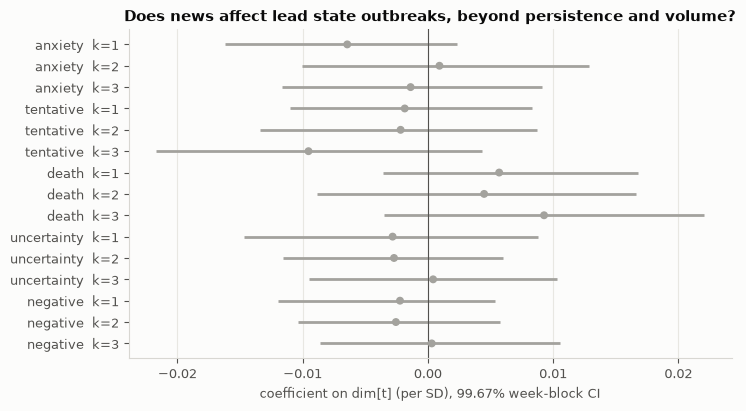

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
lab = [f"{d.removeprefix('gcam_')}  k={k}" for d, k in zip(res.dim, res.lead)]
ypos = np.arange(len(res))[::-1]
col = np.where(res.passes, BLUE, GREY)
ax.hlines(ypos, res.lo, res.hi, color=col, lw=2)
ax.scatter(res.coef, ypos, color=col, zorder=3, s=22)
ax.axvline(0, color=INK_2, lw=0.8)
ax.set_yticks(ypos, lab)
ax.set_xlabel("coefficient on dim[t] (per SD), 99.67% week-block CI")
ax.set_title("Does news affect lead state outbreaks, beyond persistence and volume?")
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

## 3. Context (descriptive, not part of the decision)

These are raw within-state correlations of each dimension with outbreaks, for lags −3…+3
weeks. They are shown only to compare the timing pattern with the volume finding: news
volume peaked at the same week or the week after outbreaks. Nothing here enters the pass
rule.

In [7]:
Q2 = P[P.n_stories > 0].copy()
yy = P.set_index(["state", "week"]).y
out = {}
for d in DIMS:
    x = Q2[d] - Q2.groupby("state")[d].transform("mean")
    r = {}
    for k in range(-3, 4):
        tgt = yy.reindex(pd.MultiIndex.from_arrays(
            [Q2.state, Q2.week + pd.Timedelta(weeks=k)])).to_numpy()
        ok = ~np.isnan(tgt)
        t = pd.Series(tgt[ok]).groupby(Q2.state.to_numpy()[ok]).transform(lambda v: v - v.mean())
        r[k] = np.corrcoef(x.to_numpy()[ok], t)[0, 1]
    out[d.removeprefix("gcam_")] = r
corr = pd.DataFrame(out).T
corr.columns = [f"k={k:+d}" for k in corr.columns]
print("within-state corr(dim[t], y[t+k]); k>0 = dim leads outbreaks")
display(corr.round(3))

within-state corr(dim[t], y[t+k]); k>0 = dim leads outbreaks


,k=-3,k=-2,k=-1,k=+0,k=+1,k=+2,k=+3
anxiety,0.004,0.004,0.017,0.016,-0.001,0.018,0.008
tentative,-0.007,-0.006,-0.038,-0.064,-0.040,-0.034,-0.053
death,0.073,0.081,0.080,0.107,0.077,0.062,0.068
uncertainty,-0.012,-0.016,0.001,-0.025,-0.012,-0.012,-0.001
negative,0.013,0.023,0.006,0.002,-0.000,-0.003,0.006


## 4. Sensitivity (a DEVIATION, labelled as such)

The pre-registration assumed GCAM's English dictionaries score English text only. The
load showed otherwise: the ~20% of articles GDELT translated into English also carry
English-dictionary counts, scored on the machine translation. The decision uses all
articles, as pre-registered. This re-run on English-source articles only is reported
for transparency and cannot change the decision.

In [8]:
res_en = fit_all(panel(sw[~sw.translingual]))
display(res_en.round(4))

,dim,lead,n,coef,lo,hi,passes
0,gcam_anxiety,1,6260,-0.0065,-0.0167,0.0034,False
1,gcam_anxiety,2,6211,0.0012,-0.0102,0.0137,False
2,gcam_anxiety,3,6162,-0.0014,-0.0139,0.0097,False
3,gcam_tentative,1,6260,-0.0019,-0.0113,0.0076,False
4,gcam_tentative,2,6211,-0.0007,-0.0106,0.0102,False
5,gcam_tentative,3,6162,-0.0079,-0.0213,0.0042,False
6,gcam_death,1,6260,0.0060,-0.0042,0.0166,False
7,gcam_death,2,6211,0.0039,-0.0079,0.0179,False
8,gcam_death,3,6162,0.0094,-0.0040,0.0251,False
9,gcam_uncertainty,1,6260,-0.0029,-0.0142,0.0090,False


## 5. Decision

In [9]:
passed = res[res.passes]
if passed.empty:
    print("NO dimension passes the pre-registered screen. Per the pre-registration: record "
          "the null and stop -- stage 2 (out-of-time lift) is not run.")
else:
    print("PASSING dimensions -> stage 2 lift test:")
    display(passed)

NO dimension passes the pre-registered screen. Per the pre-registration: record the null and stop -- stage 2 (out-of-time lift) is not run.
